In [5]:
%load_ext autoreload
%autoreload 2

In [4]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from wrf_io import *
from scipy.io import savemat
from MITRotor import IEA10MW
from itertools import product
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler

## Train data

In [15]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/'

In [16]:
casenames = [
r'sn04_vn20',
r'sn04_vn10',
r'sn04_vn05',
r'sn04_v00',
r'sn04_v05',
r'sn04_v10',
r'sn04_v20',
r'sn02_vn20',
r'sn02_vn10',
r'sn02_vn05',
r'sn02_v00',
r'sn02_v05',
r'sn02_v10',
r'sn02_v20',
r's00_vn20',
r's00_vn10',
r's00_vn05',
r's00_v00',
r's00_v05',
r's00_v10',
r's00_v20',
r's02_vn20',
r's02_vn10',
r's02_vn05',
r's02_v00',
r's02_v05',
r's02_v10',
r's02_v20',
r's04_vn20',
r's04_vn10',
r's04_vn05',
r's04_v00',
r's04_v05',
r's04_v10',
r's04_v20'
]

In [17]:
params_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/LES_data/gad_sweep/opt_params.pkl'

train_data = gpr.generate_train_data(casenames, params_path, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 9
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/LES_data
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.04, -0.02, 0, 0.02, 0.04]
veer           : [-0.2, -0.1, -0.05, 0, 0.05, 0.1, 0.2]
Ufst           : 7
excluded_pairs : []


In [18]:
gpr.print_stats(train_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
r_annulus            |    0.51206 |    0.28156 |    0.04039 |    0.98374
cot_local            |    0.96470 |    0.38678 |    0.07491 |    2.05949
ind_local            |    0.28411 |    0.13188 |   -0.12124 |    0.74628
cot_annulus          |    0.96470 |    0.33924 |    0.13868 |    1.53275
ind_annulus          |    0.28411 |    0.12264 |   -0.02265 |    0.42844
cot_rotor            |    0.91249 |    0.05552 |    0.83109 |    1.00901
ind_rotor            |    0.29376 |    0.01227 |    0.27009 |    0.31744
shears_rotor         |    0.00000 |    0.02828 |   -0.04000 |    0.04000
veers_rotor          |    0.00000 |    0.12247 |   -0.20000 |    0.20000
shears_annulus       |    0.00000 |    0.02828 |   -0.04000 |    0.04000
veers_annulus        |  

In [19]:
# Compute shear regime, generate scalars, and standardize
training_data, scalars = gpr.scale_and_encode(train_data, training=True)

cot_local: scaler trained with 1 features
ind_local: scaler trained with 1 features
cot_annulus: scaler trained with 1 features
ind_annulus: scaler trained with 1 features
cot_rotor: scaler trained with 1 features
ind_rotor: scaler trained with 1 features
shears_rotor: scaler trained with 1 features
veers_rotor: scaler trained with 1 features
shears_annulus: scaler trained with 1 features
veers_annulus: scaler trained with 1 features


In [20]:
gpr.print_stats(training_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
shear_regime_rotor   |    0.25000 |    0.43301 |    0.00000 |    1.00000
shear_regime_annulus |    0.25000 |    0.43301 |    0.00000 |    1.00000
r_annulus            |    0.51206 |    0.28156 |    0.04039 |    0.98374
cot_local            |   -0.00000 |    1.00000 |   -2.30052 |    2.83053
ind_local            |    0.00000 |    1.00000 |   -3.07360 |    3.50437
cot_annulus          |    0.00000 |    1.00000 |   -2.43496 |    1.67448
ind_annulus          |   -0.00000 |    1.00000 |   -2.50127 |    1.17676
cot_rotor            |   -0.00000 |    1.00000 |   -1.46607 |    1.73837
ind_rotor            |    0.00000 |    1.00000 |   -1.92967 |    1.93004
shears_rotor         |    0.00000 |    1.00000 |   -1.41421 |    1.41421
veers_rotor          |  

In [13]:
# Generate MATLAB tables of standardized inputs

X_rot = np.column_stack([training_data['cot_rotor'], training_data['shears_rotor'], training_data['veers_rotor']])
X_ann = np.column_stack([training_data['r_annulus'].flatten(), training_data['cot_annulus'].flatten(), training_data['shears_annulus'].flatten(), training_data['veers_annulus'].flatten()])

X_rot = np.hstack([X_rot, training_data['shear_regime_rotor']])
X_ann = np.hstack([X_ann, training_data['shear_regime_annulus']])

y_rot = training_data['ind_rotor']
y_ann = training_data['ind_annulus'].flatten()

savemat(save_path + 'wrf_10MW_ann.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

In [11]:
with open(os.path.join(save_path, 'scaler_wrf_cot_ann.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_cot_annulus'], f)

with open(os.path.join(save_path, 'scaler_wrf_ind_ann.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_ind_annulus'], f)

with open(os.path.join(save_path, 'scaler_wrf_cot_rot.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_cot_rotor'], f)

with open(os.path.join(save_path, 'scaler_wrf_ind_rot.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_ind_rotor'], f)

with open(os.path.join(save_path, 'scaler_shears_rot.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_shears_rotor'], f)

with open(os.path.join(save_path, 'scaler_veers_rot.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_veers_rotor'], f)

with open(os.path.join(save_path, 'scaler_shears_ann.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_shears_annulus'], f)

with open(os.path.join(save_path, 'scaler_veers_ann.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_veers_annulus'], f)

with open(os.path.join(save_path, 'encoder_rot.pkl'), 'wb') as f:
    pickle.dump(scalars['encoder_rotor'], f)

with open(os.path.join(save_path, 'encoder_ann.pkl'), 'wb') as f:
    pickle.dump(scalars['encoder_annulus'], f)

## Validation data

In [21]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/validation_data/'

In [22]:
casenames = [
r's000_vn150',
r's000_vn075',
r's000_vn025',
r's000_v000',
r's000_v025',
r's000_v075',
r's000_v150',
]

In [23]:
params_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/validation/gad_sweep/opt_params.pkl'

validation_data = gpr.generate_train_data(casenames, params_path, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 9
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/validation
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [0]
veer           : [-0.15, -0.075, -0.025, 0, 0.025, 0.075, 0.15]
Ufst           : 7
excluded_pairs : []


In [24]:
# Print stats of near-origin training data
gpr.print_stats(validation_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
r_annulus            |    0.51206 |    0.28156 |    0.04039 |    0.98374
cot_local            |    0.92279 |    0.33714 |    0.13473 |    1.58414
ind_local            |    0.29283 |    0.12176 |   -0.02384 |    0.43855
cot_annulus          |    0.92279 |    0.33694 |    0.14280 |    1.52898
ind_annulus          |    0.29283 |    0.12105 |    0.01508 |    0.41621
cot_rotor            |    0.86014 |    0.00799 |    0.84500 |    0.86714
ind_rotor            |    0.29908 |    0.00451 |    0.29562 |    0.30927
shears_rotor         |    0.00000 |    0.00000 |    0.00000 |    0.00000
veers_rotor          |    0.00000 |    0.09063 |   -0.15000 |    0.15000
shears_annulus       |    0.00000 |    0.00000 |    0.00000 |    0.00000
veers_annulus        |  

In [25]:
# Compute shear regime, generate scalars, and standardize
validation_data, _ = gpr.scale_and_encode(validation_data, training=False, scalars=scalars)

[cot_local] training=False, scaler expects 1, got 1
[ind_local] training=False, scaler expects 1, got 1
[cot_annulus] training=False, scaler expects 1, got 1
[ind_annulus] training=False, scaler expects 1, got 1
[cot_rotor] training=False, scaler expects 1, got 1
[ind_rotor] training=False, scaler expects 1, got 1
[shears_rotor] training=False, scaler expects 1, got 1
[veers_rotor] training=False, scaler expects 1, got 1
[shears_annulus] training=False, scaler expects 1, got 1
[veers_annulus] training=False, scaler expects 1, got 1


In [26]:
# Print stats of near-origin training data
gpr.print_stats(validation_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
shear_regime_rotor   |    0.25000 |    0.43301 |    0.00000 |    1.00000
shear_regime_annulus |    0.25000 |    0.43301 |    0.00000 |    1.00000
r_annulus            |    0.51206 |    0.28156 |    0.04039 |    0.98374
cot_local            |   -0.10837 |    0.87166 |   -2.14586 |    1.60154
ind_local            |    0.06612 |    0.92324 |   -2.33504 |    1.17102
cot_annulus          |   -0.12356 |    0.99324 |   -2.42281 |    1.66337
ind_annulus          |    0.07110 |    0.98700 |   -2.19359 |    1.07712
cot_rotor            |   -0.94279 |    0.14389 |   -1.21548 |   -0.81684
ind_rotor            |    0.43319 |    0.36786 |    0.15156 |    1.26450
shears_rotor         |   -0.00000 |    0.00000 |   -0.00000 |   -0.00000
veers_rotor          |  

In [27]:
# Generate MATLAB tables of standardized inputs

X_rot = np.column_stack([validation_data['cot_rotor'], validation_data['shears_rotor'], validation_data['veers_rotor']])
X_ann = np.column_stack([validation_data['r_annulus'].flatten(), validation_data['cot_annulus'].flatten(), validation_data['shears_annulus'].flatten(), validation_data['veers_annulus'].flatten()])

X_rot = np.hstack([X_rot, validation_data['shear_regime_rotor']])
X_ann = np.hstack([X_ann, validation_data['shear_regime_annulus']])

y_rot = validation_data['ind_rotor']
y_ann = validation_data['ind_annulus'].flatten()

savemat(save_path + 'wrf_10MW_ann.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

## Test data

In [28]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/'

In [29]:
casenames = [
r's000_vn250',
r's000_vn150',
r's000_vn070',
r's000_vn035',
r's000_vn010',
r's000_v000',
r's000_v010',
r's000_v035',
r's000_v070',
r's000_v150',
r's000_v250',
]

In [25]:
# Path to the file
pkl_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/OOS_SV/gad_sweep/opt_params.pkl'

# Load the pickle file
with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

data['excluded_pairs'] = []
data

# Save it back to the original file
with open(pkl_path, 'wb') as f:
    pickle.dump(data, f)

In [31]:
params_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/test/gad_sweep/opt_params.pkl'

test_data = gpr.generate_train_data(casenames, params_path, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 9
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/test
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [0]
veer           : [-0.25, -0.15, -0.07, -0.035, -0.01, 0, 0.01, 0.035, 0.07, 0.15, 0.25]
Ufst           : 7
excluded_pairs : []


In [32]:
# Print stats of near-origin training data
gpr.print_stats(test_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
r_annulus            |    0.51206 |    0.28156 |    0.04039 |    0.98374
cot_local            |    0.91732 |    0.33682 |    0.12010 |    1.58414
ind_local            |    0.29514 |    0.12215 |   -0.02396 |    0.46707
cot_annulus          |    0.91732 |    0.33651 |    0.13409 |    1.52906
ind_annulus          |    0.29514 |    0.12114 |    0.01503 |    0.43150
cot_rotor            |    0.85408 |    0.01762 |    0.81521 |    0.86724
ind_rotor            |    0.30130 |    0.00812 |    0.29549 |    0.32334
shears_rotor         |    0.00000 |    0.00000 |    0.00000 |    0.00000
veers_rotor          |    0.00000 |    0.12879 |   -0.25000 |    0.25000
shears_annulus       |    0.00000 |    0.00000 |    0.00000 |    0.00000
veers_annulus        |  

In [33]:
# Compute shear regime, generate scalars, and standardize
test_data, _ = gpr.scale_and_encode(test_data, training=False, scalars=scalars)

[cot_local] training=False, scaler expects 1, got 1
[ind_local] training=False, scaler expects 1, got 1
[cot_annulus] training=False, scaler expects 1, got 1
[ind_annulus] training=False, scaler expects 1, got 1
[cot_rotor] training=False, scaler expects 1, got 1
[ind_rotor] training=False, scaler expects 1, got 1
[shears_rotor] training=False, scaler expects 1, got 1
[veers_rotor] training=False, scaler expects 1, got 1
[shears_annulus] training=False, scaler expects 1, got 1
[veers_annulus] training=False, scaler expects 1, got 1


In [34]:
# Print stats of near-origin training data
gpr.print_stats(test_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
shear_regime_rotor   |    0.25000 |    0.43301 |    0.00000 |    1.00000
shear_regime_annulus |    0.25000 |    0.43301 |    0.00000 |    1.00000
r_annulus            |    0.51206 |    0.28156 |    0.04039 |    0.98374
cot_local            |   -0.12251 |    0.87083 |   -2.18370 |    1.60154
ind_local            |    0.08360 |    0.92617 |   -2.33598 |    1.38727
cot_annulus          |   -0.13968 |    0.99197 |   -2.44847 |    1.66361
ind_annulus          |    0.08989 |    0.98774 |   -2.19404 |    1.20172
cot_rotor            |   -1.05191 |    0.31732 |   -1.75199 |   -0.81498
ind_rotor            |    0.61417 |    0.66174 |    0.14096 |    2.41127
shears_rotor         |   -0.00000 |    0.00000 |   -0.00000 |   -0.00000
veers_rotor          |  

In [37]:
# Generate MATLAB tables of standardized inputs

X_rot = np.column_stack([test_data['cot_rotor'], test_data['shears_rotor'], test_data['veers_rotor']])
X_ann = np.column_stack([test_data['r_annulus'].flatten(), test_data['cot_annulus'].flatten(), test_data['shears_annulus'].flatten(), test_data['veers_annulus'].flatten()])

X_rot = np.hstack([X_rot, test_data['shear_regime_rotor']])
X_ann = np.hstack([X_ann, test_data['shear_regime_annulus']])

y_rot = test_data['ind_rotor']
y_ann = test_data['ind_annulus'].flatten()

savemat(save_path + 'wrf_10MW_ann.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

## Test data (OOS rt)

In [31]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/'

In [39]:
casenames = [
# r'sn030_vn200',
# r'sn030_vn100',
# r'sn030_vn050',
# r'sn030_vn025',
# r'sn030_v000',
# r'sn030_v025',
# r'sn030_v050',
# r'sn030_v100',
# r'sn030_v200',
# r'sn020_vn200',
r'sn020_vn100',
# r'sn020_vn050',
# r'sn020_vn025',
r'sn020_v000',
# r'sn020_v025',
# r'sn020_v050',
r'sn020_v100',
# r'sn020_v200',
# r'sn010_vn200',
# r'sn010_vn100',
# r'sn010_vn050',
# r'sn010_vn025',
# r'sn010_v000',
# r'sn010_v025',
# r'sn010_v050',
# r'sn010_v100',
# r'sn010_v200',
# r's000_vn200',
r's000_vn100',
# r's000_vn050',
# r's000_vn025',
r's000_v000',
# r's000_v025',
# r's000_v050',
r's000_v100',
# r's000_v200',
# r's010_vn200',
# r's010_vn100',
# r's010_vn050',
# r's010_vn025',
# r's010_v000',
# r's010_v025',
# r's010_v050',
# r's010_v100',
# r's010_v200',
# r's020_vn200',
r's020_vn100',
# r's020_vn050',
# r's020_vn025',
r's020_v000',
# r's020_v025',
# r's020_v050',
r's020_v100',
# r's020_v200',
# r's030_vn200',
# r's030_vn100',
# r's030_vn050',
# r's030_vn025',
# r's030_v000',
# r's030_v025',
# r's030_v050',
# r's030_v100',
# r's030_v200'
]

In [40]:
params_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/OOS_rt_up/gad_sweep/opt_params.pkl'

test_OOSrt_up_data = gpr.generate_train_data(casenames, params_path, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 10
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/OOS_rt_up
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03]
veer           : [-0.2, -0.1, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.2]
excluded_pairs : []
Ufst           : 7


In [41]:
# Print stats of near-origin training data
gpr.print_stats(test_OOSrt_up_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
r_annulus            |    0.51206 |    0.28156 |    0.04039 |    0.98374
cot_local            |    0.71581 |    0.29914 |    0.07797 |    1.11967
ind_local            |    0.24220 |    0.13855 |   -0.23131 |    0.52166
cot_annulus          |    0.71581 |    0.29267 |    0.09639 |    1.02050
ind_annulus          |    0.24220 |    0.10601 |    0.01976 |    0.34607
cot_rotor            |    0.68629 |    0.00416 |    0.67889 |    0.69281
ind_rotor            |    0.24566 |    0.00530 |    0.23923 |    0.25607
shears_rotor         |    0.00000 |    0.02000 |   -0.03000 |    0.03000
veers_rotor          |   -0.00000 |    0.10865 |   -0.20000 |    0.20000
shears_annulus       |   -0.03000 |    0.00000 |   -0.03000 |   -0.03000
veers_annulus        |  

In [37]:
# Compute shear regime, generate scalars, and standardize
test_OOSrt_up_data, _ = gpr.scale_and_encode(test_OOSrt_up_data, training=False, scalars=scalars)

[cot_local] training=False, scaler expects 1, got 1
[ind_local] training=False, scaler expects 1, got 1
[cot_annulus] training=False, scaler expects 1, got 1
[ind_annulus] training=False, scaler expects 1, got 1
[cot_rotor] training=False, scaler expects 1, got 1
[ind_rotor] training=False, scaler expects 1, got 1
[shears_rotor] training=False, scaler expects 1, got 1
[veers_rotor] training=False, scaler expects 1, got 1
[shears_annulus] training=False, scaler expects 1, got 1
[veers_annulus] training=False, scaler expects 1, got 1


In [38]:
# Print stats of near-origin training data
gpr.print_stats(test_OOSrt_up_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
shear_regime_rotor   |    0.25000 |    0.43301 |    0.00000 |    1.00000
shear_regime_annulus |    0.25000 |    0.43301 |    0.00000 |    1.00000
r_annulus            |    0.51206 |    0.28156 |    0.04039 |    0.98374
cot_local            |    0.01415 |    0.97069 |   -2.05562 |    1.32466
ind_local            |    0.01575 |    0.93079 |   -3.16538 |    1.89323
cot_annulus          |    0.01452 |    0.97488 |   -2.04875 |    1.02947
ind_annulus          |    0.02154 |    0.97378 |   -2.02168 |    0.97569
cot_rotor            |   -0.09773 |    0.64605 |   -1.24525 |    0.91524
ind_rotor            |    0.10275 |    0.55551 |   -0.57187 |    1.19443
shears_rotor         |   -0.00000 |    1.07511 |   -1.61267 |    1.61267
veers_rotor          |  

In [ ]:
# Generate MATLAB tables of standardized inputs

X_rot = np.column_stack([test_data['cot_rotor'], test_data['shears_rotor'], test_data['veers_rotor']])
X_ann = np.column_stack([test_data['r_annulus'].flatten(), test_data['cot_annulus'].flatten(), test_data['shears_annulus'].flatten(), test_data['veers_annulus'].flatten()])

y_rot = test_data['ind_rotor']
y_ann = test_data['ind_annulus'].flatten()

savemat(save_path + 'wrf_10MW_ann.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

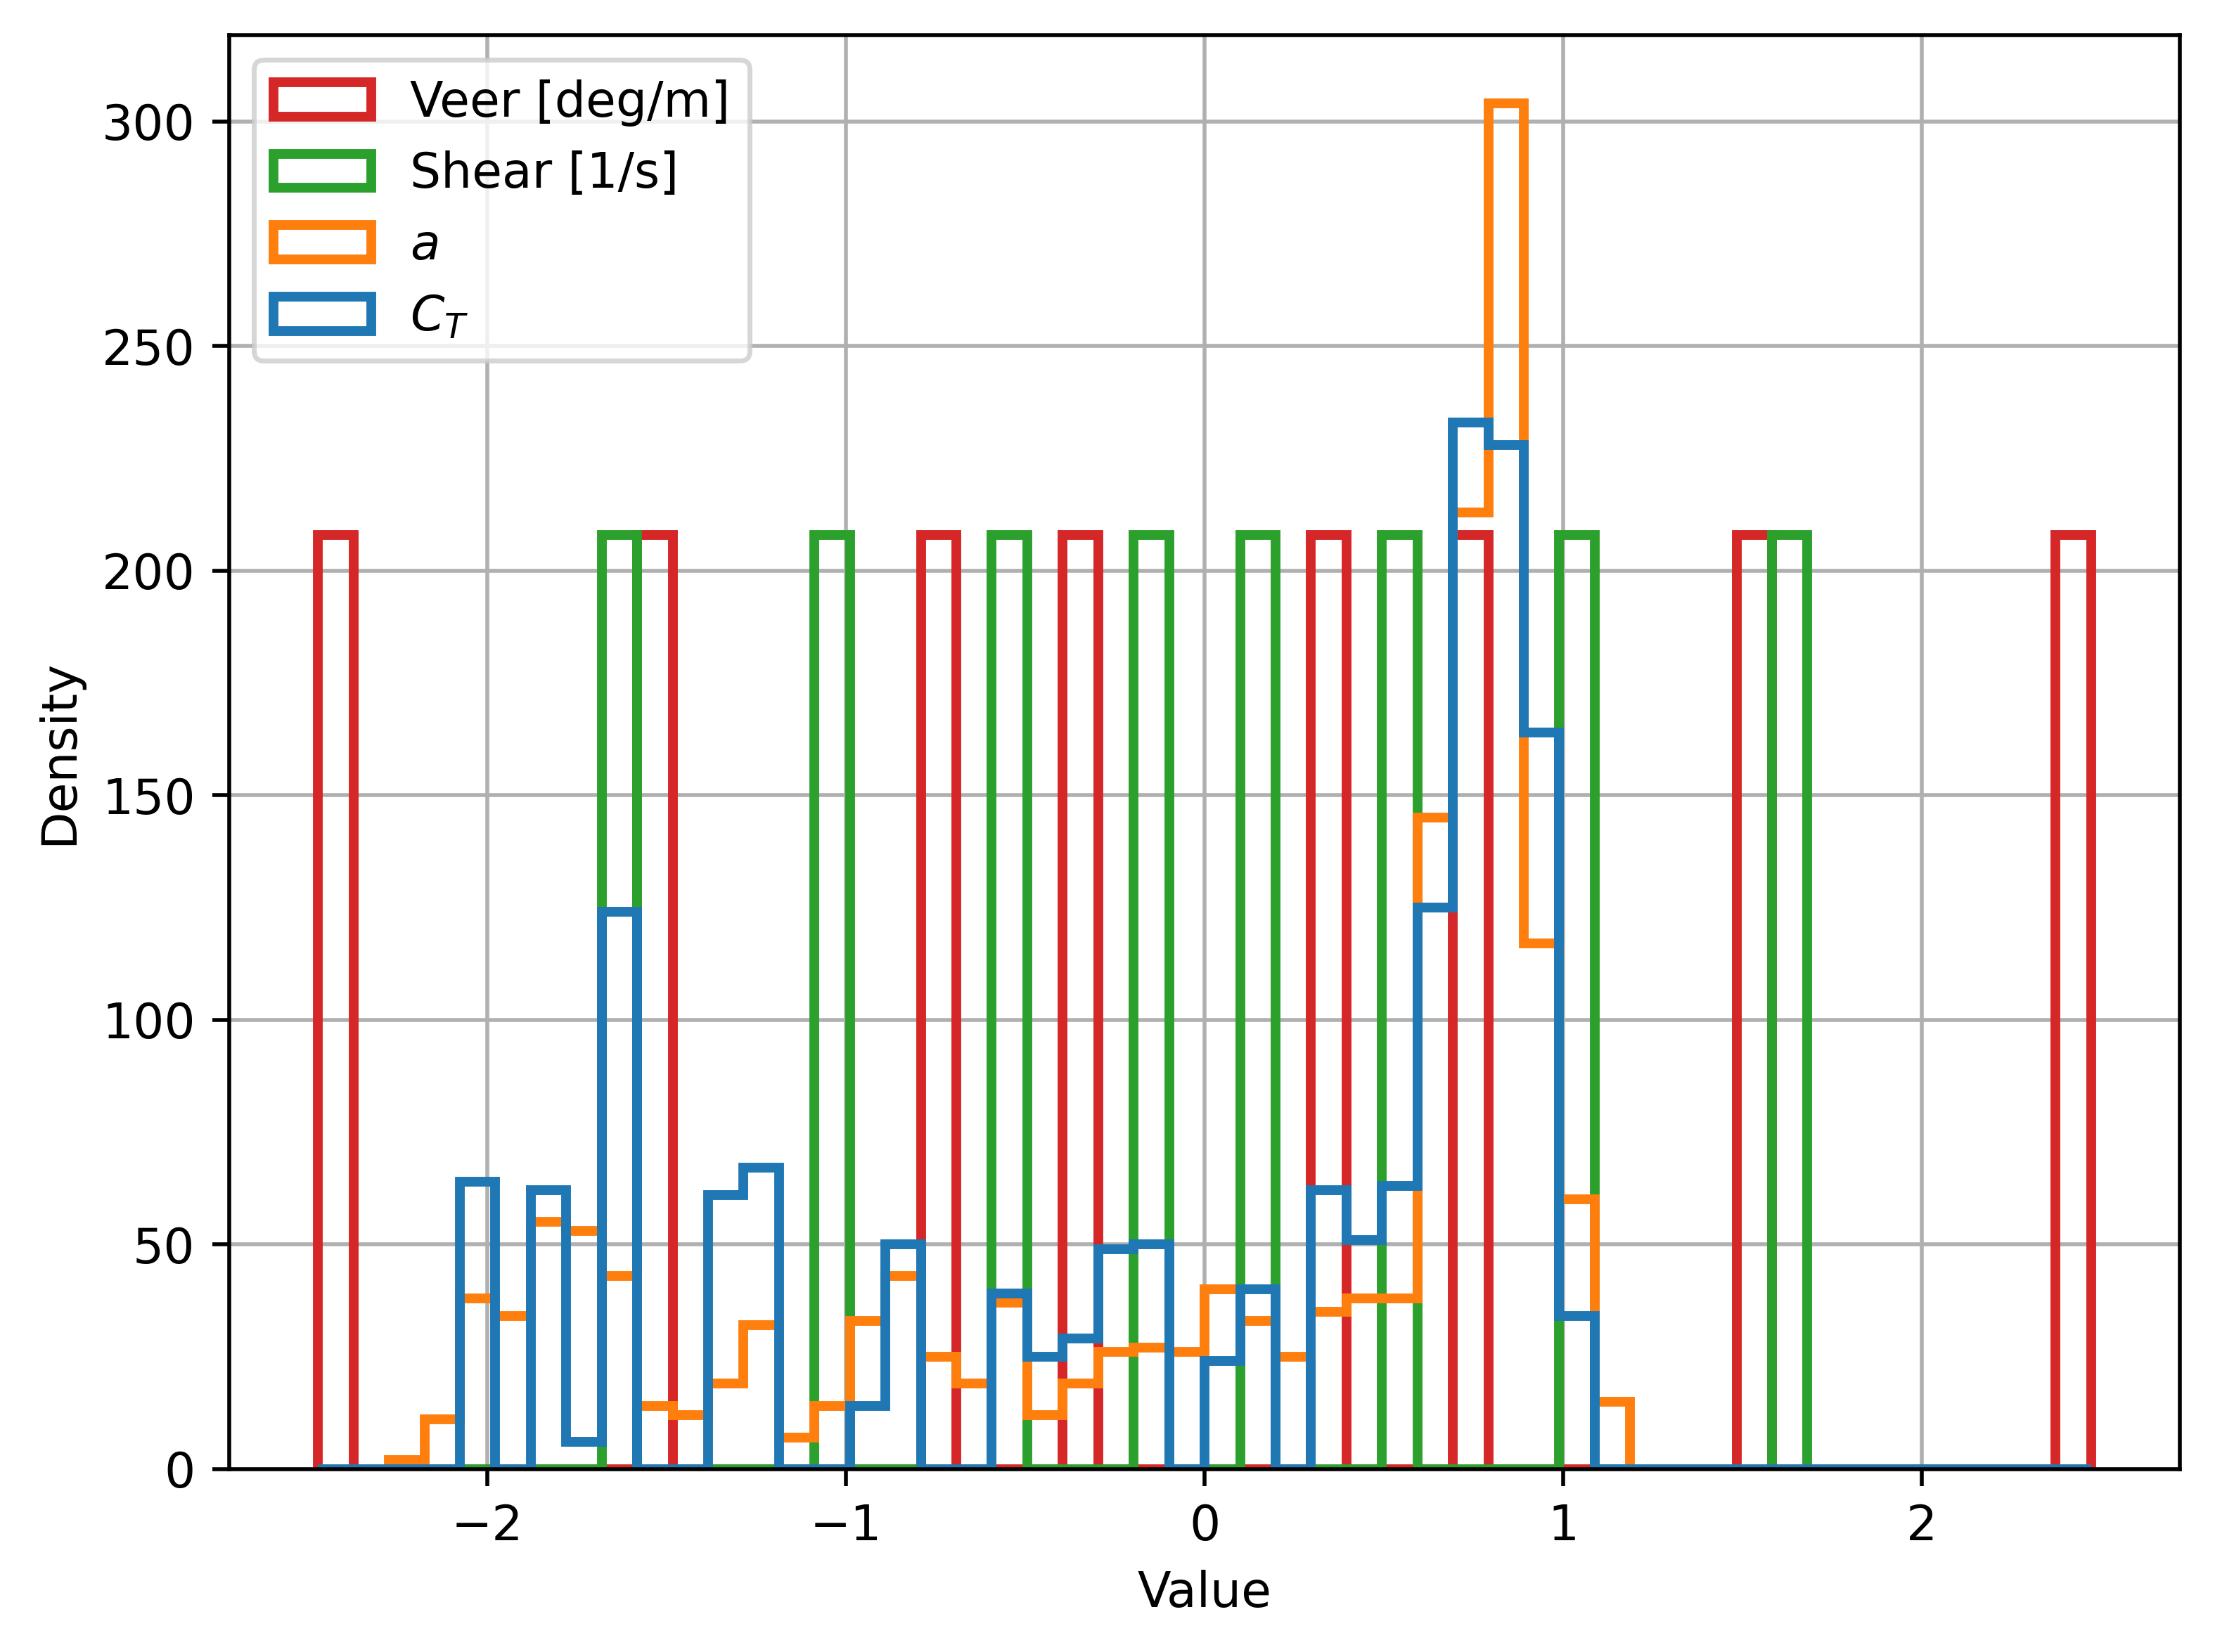

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
# data1 = training_data['cot_annulus'].flatten()
# data2 = training_data['ind_annulus'].flatten()
# data3 = training_data['shears_annulus'].flatten()
# data4 = training_data['veers_annulus'].flatten()

data1 = validation_data['cot_annulus'].flatten()
data2 = validation_data['ind_annulus'].flatten()
data3 = validation_data['shears_annulus'].flatten()
data4 = validation_data['veers_annulus'].flatten()

# Plot as stair/step histograms
plt.hist([data1, data2, data3, data4],
         bins=50,
         density=False,
         histtype='step',
         linewidth=2,
         label=['$C_T$', '$a$', 'Shear [1/s]', 'Veer [deg/m]'])

plt.xlabel('Value')
plt.ylabel('Density')
# plt.title('Step Histogram of Multiple Datasets')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
